# Piste B — Ré-entraînement YOLO sur images en mouvement

Améliore le rappel sur vidéos en entraînant YOLO sur :
- **Source 1** : 1 000 images statiques HyperKvasir annotées par médecins
- **Source 2** : frames extraites des vidéos HyperKvasir, auto-annotées par YOLO

**Plan :** Installation → Drive → Source 1 → Source 2 → Fusion → Entraînement → Comparaison

## 1. Installation et imports

In [1]:
!pip install ultralytics opencv-python-headless -q

import os, cv2, json, random, shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from ultralytics import YOLO
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

print('Imports OK')


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 28.7 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Imports OK


## 2. Montage Google Drive + configuration

In [2]:
from google.colab import drive
drive.mount('/content/drive')

# --- Chemins a adapter selon ton Drive ---
YOLO_WEIGHTS_CURRENT = '/content/drive/MyDrive/best.pt'
VIDEO_FOLDER         = '/content/drive/MyDrive/polyps/'
STATIC_IMAGES_FOLDER = '/content/drive/MyDrive/hyper-kvasir-segmented-images/segmented-images/images'
STATIC_BBOX_JSON     = '/content/drive/MyDrive/hyper-kvasir-segmented-images/segmented-images/bounding-boxes.json'

# --- Parametres ---
FRAMES_PER_VIDEO = 50
CONF_THRESHOLD   = 0.25
FRAME_SKIP       = 10
EPOCHS           = 50
IMG_SIZE         = 640
WORK_DIR         = '/content/yolo_video_training'
os.makedirs(WORK_DIR, exist_ok=True)
print('Configuration OK')


Mounted at /content/drive
Configuration OK


In [4]:
import json

with open(STATIC_BBOX_JSON, "r") as f:
    data = json.load(f)

print(type(data))

if isinstance(data, dict):
    print("Nombre d'entrées :", len(data))
    print("Premières clés :", list(data.keys())[:5])

elif isinstance(data, list):
    print("Nombre d'éléments :", len(data))
    print(data[0])

<class 'dict'>
Nombre d'entrées : 1000
Premières clés : ['0dad158b-043d-427d-a656-b1034b9a6a0d', 'aa4e9e0a-de77-4c33-aa35-5fa3f6b3de41', '8b0402da-a0ef-4b97-a6d6-6ce96bdcf750', '90d30949-a733-4e0e-8fdc-b8687e8548ad', '82dea4ce-e7d5-460f-a28f-97c654ce1486']


In [5]:
import json

with open(STATIC_BBOX_JSON, "r") as f:
    bbox_all = json.load(f)

first_key = next(iter(bbox_all))

print("Image :", first_key)
print(bbox_all[first_key])

Image : 0dad158b-043d-427d-a656-b1034b9a6a0d
{'height': 529, 'width': 622, 'bbox': [{'label': 'polyp', 'xmin': 38, 'ymin': 5, 'xmax': 430, 'ymax': 338}]}


In [6]:
from pprint import pprint

pprint(bbox_all[first_key])

{'bbox': [{'label': 'polyp', 'xmax': 430, 'xmin': 38, 'ymax': 338, 'ymin': 5}],
 'height': 529,
 'width': 622}


In [7]:
import os
import json

with open(STATIC_BBOX_JSON, "r") as f:
    bbox_all = json.load(f)

print("Première clé JSON :", next(iter(bbox_all.keys())))
print("Première image :", os.listdir(STATIC_IMAGES_FOLDER)[0])

Première clé JSON : 0dad158b-043d-427d-a656-b1034b9a6a0d
Première image : 00f98835-8fd8-43fe-960d-f4a1159c30f1.jpg


## 3. Chargement du modele YOLO actuel

In [14]:
model_current = YOLO(YOLO_WEIGHTS_CURRENT)
print('Modele YOLO actuel charge :', YOLO_WEIGHTS_CURRENT)


Modele YOLO actuel charge : /content/drive/MyDrive/best.pt


In [8]:
import os
import json

with open(STATIC_BBOX_JSON, "r") as f:
    bbox_all = json.load(f)

image_stems = {
    os.path.splitext(f)[0]
    for f in os.listdir(STATIC_IMAGES_FOLDER)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
}

json_keys = set(bbox_all.keys())

print("Nombre d'images :", len(image_stems))
print("Nombre de clés JSON :", len(json_keys))
print("Correspondances :", len(image_stems & json_keys))

# Afficher quelques exemples d'images sans annotation
missing = list(image_stems - json_keys)
print("\nExemples d'images sans clé JSON :", missing[:10])

# Afficher quelques exemples de clés JSON sans image
extra = list(json_keys - image_stems)
print("\nExemples de clés JSON sans image :", extra[:10])

Nombre d'images : 1000
Nombre de clés JSON : 1000
Correspondances : 1000

Exemples d'images sans clé JSON : []

Exemples de clés JSON sans image : []


## 4. Source 1 — Images statiques HyperKvasir annotees

1 000 images de polypes avec vraies bounding boxes (format JSON).
On les convertit au format YOLO (coordonnees normalisees).

In [9]:
print("STATIC_IMAGES_FOLDER =", STATIC_IMAGES_FOLDER)
print("STATIC_BBOX_JSON =", STATIC_BBOX_JSON)
print("WORK_DIR =", WORK_DIR)

STATIC_IMAGES_FOLDER = /content/drive/MyDrive/hyper-kvasir-segmented-images/segmented-images/images
STATIC_BBOX_JSON = /content/drive/MyDrive/hyper-kvasir-segmented-images/segmented-images/bounding-boxes.json
WORK_DIR = /content/yolo_video_training


In [10]:
import os
import json

with open(STATIC_BBOX_JSON, "r") as f:
    bbox_all = json.load(f)

img_file = next(
    f for f in os.listdir(STATIC_IMAGES_FOLDER)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
)

stem = os.path.splitext(img_file)[0]

print("Image :", img_file)
print("Stem :", stem)
print("Existe dans le JSON ?", stem in bbox_all)

info = bbox_all[stem]
print(info)

Image : 00f98835-8fd8-43fe-960d-f4a1159c30f1.jpg
Stem : 00f98835-8fd8-43fe-960d-f4a1159c30f1
Existe dans le JSON ? True
{'height': 530, 'width': 571, 'bbox': [{'label': 'polyp', 'xmin': 321, 'ymin': 98, 'xmax': 505, 'ymax': 400}]}


In [11]:
import os
import json
import shutil
from PIL import Image

static_out_img = os.path.join(WORK_DIR, "source1", "images")
static_out_lbl = os.path.join(WORK_DIR, "source1", "labels")

os.makedirs(static_out_img, exist_ok=True)
os.makedirs(static_out_lbl, exist_ok=True)

# Charger le fichier unique contenant toutes les annotations
with open(STATIC_BBOX_JSON, "r") as f:
    bbox_all = json.load(f)

static_converted = 0
static_skipped = 0

for img_file in os.listdir(STATIC_IMAGES_FOLDER):

    if not img_file.lower().endswith((".jpg", ".jpeg", ".png")):
        continue

    stem = os.path.splitext(img_file)[0]

    # Vérifier que l'image possède une annotation
    if stem not in bbox_all:
        static_skipped += 1
        continue

    annotation = bbox_all[stem]

    W = annotation["width"]
    H = annotation["height"]

    boxes = annotation["bbox"]

    if len(boxes) == 0:
        static_skipped += 1
        continue

    # Copier l'image
    src_img = os.path.join(STATIC_IMAGES_FOLDER, img_file)
    dst_img = os.path.join(static_out_img, img_file)
    shutil.copy(src_img, dst_img)

    # Créer le fichier YOLO
    label_path = os.path.join(static_out_lbl, stem + ".txt")

    with open(label_path, "w") as f:

        for box in boxes:

            xmin = box["xmin"]
            ymin = box["ymin"]
            xmax = box["xmax"]
            ymax = box["ymax"]

            xc = ((xmin + xmax) / 2) / W
            yc = ((ymin + ymax) / 2) / H
            bw = (xmax - xmin) / W
            bh = (ymax - ymin) / H

            # Classe 0 = polyp
            f.write(f"0 {xc:.6f} {yc:.6f} {bw:.6f} {bh:.6f}\n")

    static_converted += 1

print(f"Source 1 — Converties : {static_converted}")
print(f"Source 1 — Ignorees : {static_skipped}")

Source 1 — Converties : 1000
Source 1 — Ignorees : 0


## 5. Source 2 — Frames video + auto-annotation YOLO (pseudo-labeling)

On extrait des frames des videos HyperKvasir et on applique le modele
YOLO actuel pour generer des bounding boxes automatiques.
Seules les frames avec une detection sont conservees.

In [15]:
video_out_img = os.path.join(WORK_DIR, 'source2', 'images')
video_out_lbl = os.path.join(WORK_DIR, 'source2', 'labels')
os.makedirs(video_out_img, exist_ok=True)
os.makedirs(video_out_lbl, exist_ok=True)

video_files = [f for f in os.listdir(VIDEO_FOLDER) if f.endswith('.avi')]
print(f'Videos trouvees : {len(video_files)}')

total_with_detection = 0

for video_file in video_files:
    vpath = os.path.join(VIDEO_FOLDER, video_file)
    vstem = os.path.splitext(video_file)[0]
    cap   = cv2.VideoCapture(vpath)
    frame_idx = 0
    extracted = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break
        if frame_idx % FRAME_SKIP == 0 and extracted < FRAMES_PER_VIDEO:
            result = model_current.predict(frame, conf=CONF_THRESHOLD, verbose=False)[0]
            if len(result.boxes) > 0:
                fname = vstem + '_f' + str(frame_idx).zfill(6)
                img_path = os.path.join(video_out_img, fname + '.jpg')
                lbl_path = os.path.join(video_out_lbl, fname + '.txt')
                cv2.imwrite(img_path, frame)
                H, W = frame.shape[:2]
                lines = []
                for box in result.boxes:
                    x1, y1, x2, y2 = box.xyxy[0].tolist()
                    xc = ((x1 + x2) / 2) / W
                    yc = ((y1 + y2) / 2) / H
                    bw = (x2 - x1) / W
                    bh = (y2 - y1) / H
                    lines.append(f'0 {xc:.6f} {yc:.6f} {bw:.6f} {bh:.6f}')
                with open(lbl_path, 'w') as f:
                    f.write('\n'.join(lines))
                extracted += 1
                total_with_detection += 1
        frame_idx += 1

    cap.release()
    print(f'  {video_file}: {extracted} frames extraites')

print(f'\nSource 2 — Total frames avec detection : {total_with_detection}')


Videos trouvees : 72
  a47dce89-f633-4c51-a4e7-9506ca513839.avi: 3 frames extraites
  f9a29376-1672-4b6f-97c7-8ed490a58390.avi: 3 frames extraites
  a6340694-7315-4e1b-b8a5-c048df133d79.avi: 16 frames extraites
  76866169-90d1-42fa-ab86-0ee7bb56ea01.avi: 42 frames extraites
  89a4fc64-d698-4c09-ad17-f89257182cc2.avi: 50 frames extraites
  73bad003-9b4b-43b7-a8bf-04b6a66ecb1e.avi: 1 frames extraites
  26c197fc-9b0a-47da-a44c-4cff4ed3b95d.avi: 50 frames extraites
  8db217ce-cfd3-4aba-946d-8d2ca9f6d72e.avi: 50 frames extraites
  39de6fcf-d914-4c88-87d6-f0d11d865fd2.avi: 50 frames extraites
  8a1d3d3c-a05f-4837-9c79-de38ecb4ac2e.avi: 1 frames extraites
  7cfdbb45-a132-4a04-8e6e-72270e3c7792.avi: 50 frames extraites
  07bf7341-7ddd-44a0-8b31-36842b8761fa.avi: 47 frames extraites
  f75949a3-bd10-4762-a7d5-1e5e42fae8e4.avi: 50 frames extraites
  5c5b3692-51a0-42fc-8836-923448e3b018.avi: 35 frames extraites
  4c0cae22-4945-4f17-a60b-23688b485d91.avi: 6 frames extraites
  5b2f37fb-8365-4b75-85c

## 6. Fusion des deux sources + split train/val

In [16]:
all_samples = []
for src_dir, lbl_dir in [(static_out_img, static_out_lbl), (video_out_img, video_out_lbl)]:
    for fname in os.listdir(src_dir):
        if not fname.lower().endswith(('.jpg', '.jpeg', '.png')):
            continue
        stem     = os.path.splitext(fname)[0]
        lbl_path = os.path.join(lbl_dir, stem + '.txt')
        if os.path.exists(lbl_path):
            all_samples.append((os.path.join(src_dir, fname), lbl_path))

random.seed(42)
random.shuffle(all_samples)
n       = len(all_samples)
n_train = int(0.8 * n)
splits  = {'train': all_samples[:n_train], 'val': all_samples[n_train:]}

dataset_dir = os.path.join(WORK_DIR, 'dataset_video')
for split, samples in splits.items():
    os.makedirs(os.path.join(dataset_dir, 'images', split), exist_ok=True)
    os.makedirs(os.path.join(dataset_dir, 'labels', split), exist_ok=True)
    for img_path, lbl_path in samples:
        fname = os.path.basename(img_path)
        stem  = os.path.splitext(fname)[0]
        shutil.copy(img_path, os.path.join(dataset_dir, 'images', split, fname))
        shutil.copy(lbl_path, os.path.join(dataset_dir, 'labels', split, stem + '.txt'))

print(f'Dataset fusionne : {n} images | Train : {n_train} | Val : {n - n_train}')
print(f'  Source 1 (statiques) : {static_converted}')
print(f'  Source 2 (video)     : {total_with_detection}')


Dataset fusionne : 2822 images | Train : 2257 | Val : 565
  Source 1 (statiques) : 1000
  Source 2 (video)     : 1822


In [17]:
yaml_path = os.path.join(WORK_DIR, 'video_training.yaml')
yaml_content = 'path: ' + dataset_dir + '\ntrain: images/train\nval: images/val\n\nnames:\n  0: polype\n'
with open(yaml_path, 'w') as f:
    f.write(yaml_content)
print(yaml_content)


path: /content/yolo_video_training/dataset_video
train: images/train
val: images/val

names:
  0: polype



## 7. Verification visuelle du dataset (quelques exemples)

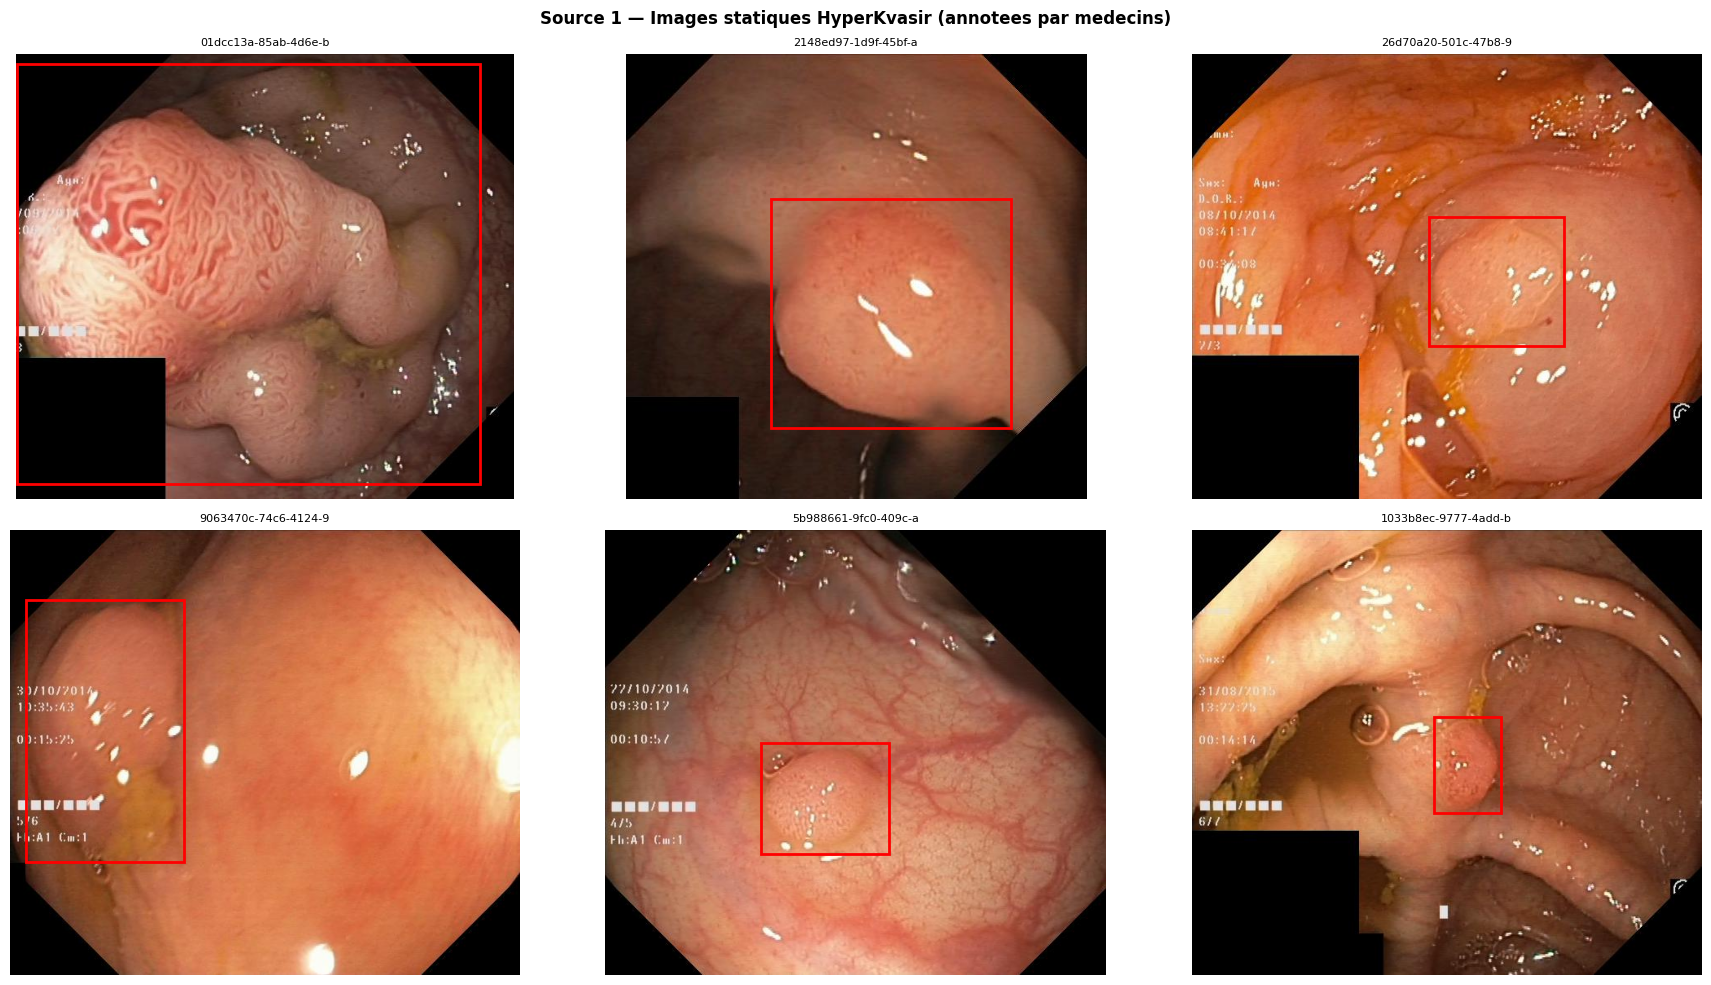

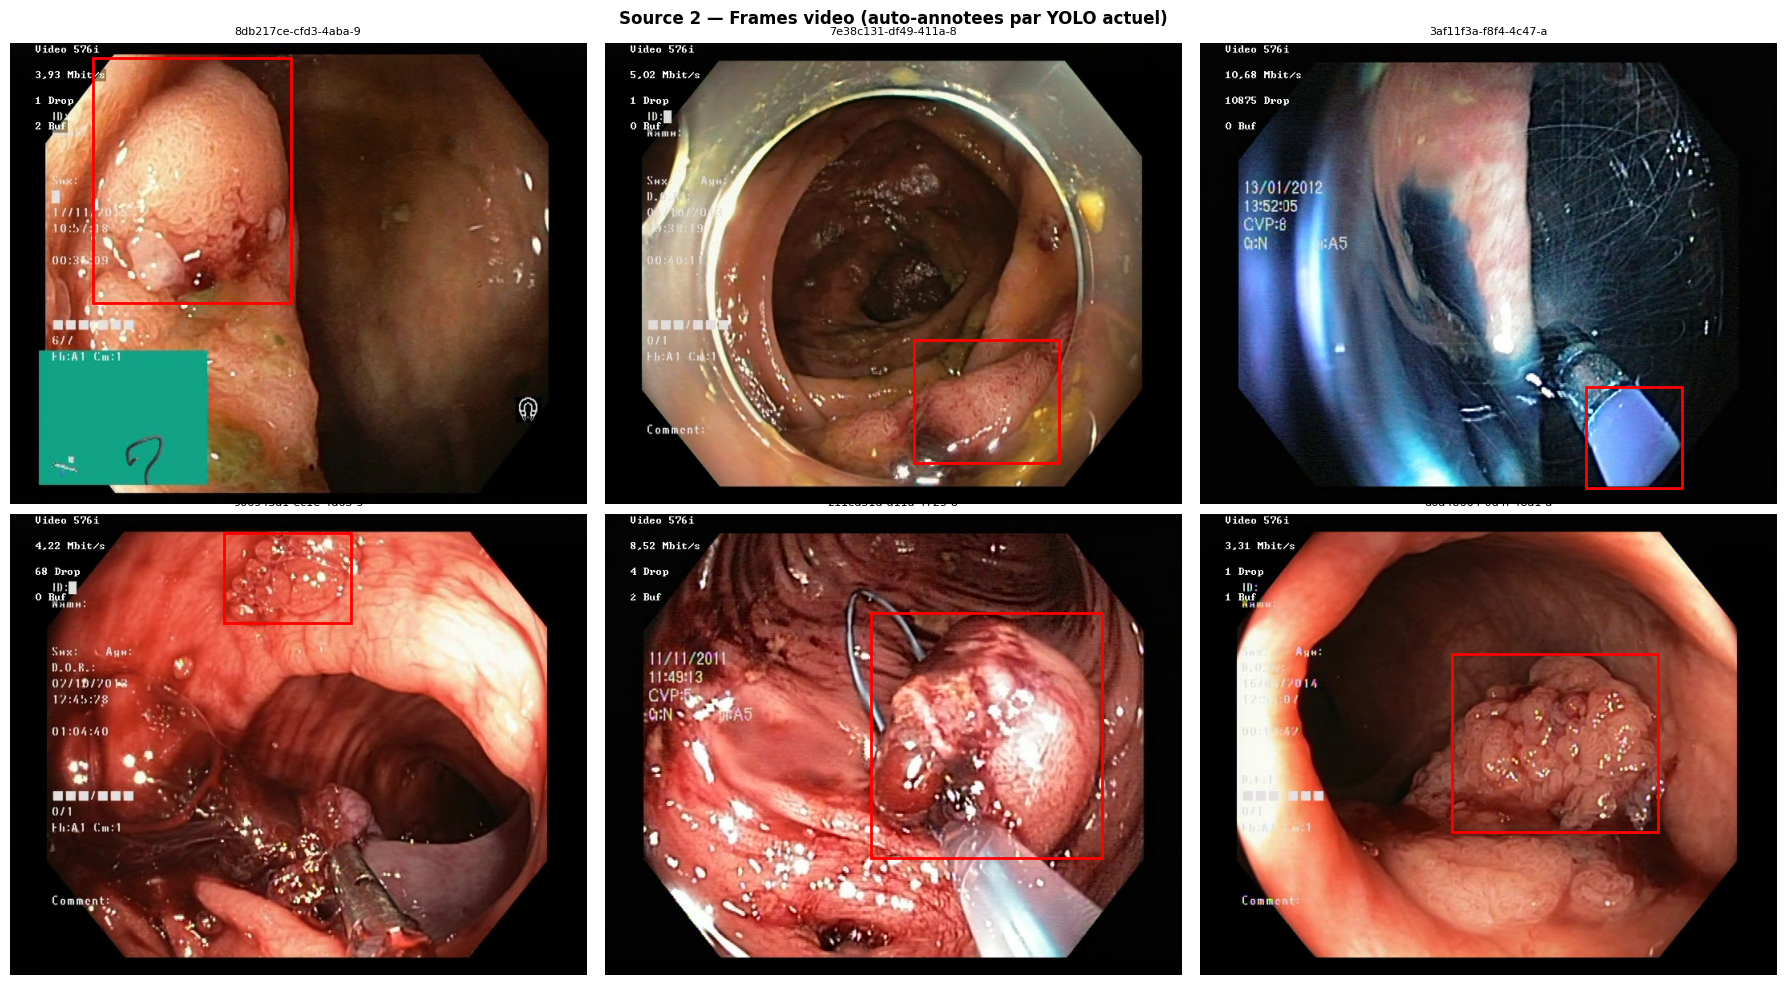

In [18]:
def show_samples_grid(images_dir, labels_dir, title, n=6):
    files = [f for f in os.listdir(images_dir) if f.endswith(('.jpg', '.png'))][:n]
    if not files:
        print('Aucune image trouvee dans', images_dir)
        return
    cols = min(3, len(files))
    rows = (len(files) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(6*cols, 5*rows))
    axes = axes.flatten() if len(files) > 1 else [axes]
    for ax, fname in zip(axes, files):
        stem = os.path.splitext(fname)[0]
        img  = Image.open(os.path.join(images_dir, fname))
        W, H = img.size
        ax.imshow(img)
        lbl_path = os.path.join(labels_dir, stem + '.txt')
        if os.path.exists(lbl_path):
            for line in open(lbl_path).read().splitlines():
                if not line.strip(): continue
                _, xc, yc, bw, bh = map(float, line.split())
                x1 = (xc - bw/2) * W
                y1 = (yc - bh/2) * H
                ax.add_patch(patches.Rectangle((x1, y1), bw*W, bh*H,
                    linewidth=2, edgecolor='red', facecolor='none'))
        ax.set_title(fname[:20], fontsize=8)
        ax.axis('off')
    for ax in axes[len(files):]:
        ax.axis('off')
    plt.suptitle(title, fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

show_samples_grid(static_out_img, static_out_lbl,
    'Source 1 — Images statiques HyperKvasir (annotees par medecins)')
show_samples_grid(video_out_img, video_out_lbl,
    'Source 2 — Frames video (auto-annotees par YOLO actuel)')


## 8. Re-entrainement YOLO sur le dataset fusionne

On part des poids actuels (`best.pt`) — le modele conserve ce qu'il
a appris et s'ameliore sur les images en mouvement (fine-tuning).

In [19]:
model_new = YOLO(YOLO_WEIGHTS_CURRENT)

results_train = model_new.train(
    data=yaml_path,
    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    batch=16,
    name='yolo_polype_video',
    exist_ok=True,
)

new_weights_path = 'runs/detect/yolo_polype_video/weights/best.pt'
print('Nouveau modele sauvegarde :', new_weights_path)


Ultralytics 8.4.90 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolo_video_training/video_training.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/MyDrive/best.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo_polype_video, nbs=64, nms=False, opset=None, optimize=Fals

## 9. Evaluation et comparaison avant / apres re-entrainement

In [20]:
val_images_dir = os.path.join(dataset_dir, 'images', 'val')
val_labels_dir = os.path.join(dataset_dir, 'labels', 'val')

def evaluate_on_val(model, img_dir, lbl_dir, conf=0.25):
    y_true, y_pred = [], []
    for fname in os.listdir(img_dir):
        if not fname.lower().endswith(('.jpg', '.jpeg', '.png')):
            continue
        stem  = os.path.splitext(fname)[0]
        lbl   = open(os.path.join(lbl_dir, stem + '.txt')).read().strip()
        true  = 1 if lbl else 0
        pred  = model.predict(os.path.join(img_dir, fname), conf=conf, verbose=False)[0]
        y_pred.append(1 if len(pred.boxes) > 0 else 0)
        y_true.append(true)
    return {
        'accuracy':  round(accuracy_score(y_true, y_pred), 4),
        'precision': round(precision_score(y_true, y_pred, zero_division=0), 4),
        'recall':    round(recall_score(y_true, y_pred, zero_division=0), 4),
        'cm':        confusion_matrix(y_true, y_pred),
    }

print('Evaluation modele ACTUEL...')
metrics_old = evaluate_on_val(model_current, val_images_dir, val_labels_dir)

print('Evaluation NOUVEAU modele...')
model_retrained = YOLO(new_weights_path)
metrics_new = evaluate_on_val(model_retrained, val_images_dir, val_labels_dir)

print('=' * 55)
print('COMPARAISON AVANT / APRES RE-ENTRAINEMENT')
print('=' * 55)
print('{:<20} {:>10} {:>10} {:>10}'.format('Metrique', 'Avant', 'Apres', 'Delta'))
print('-' * 55)
for metric in ['accuracy', 'precision', 'recall']:
    before = metrics_old[metric]
    after  = metrics_new[metric]
    delta  = round(after - before, 4)
    sign   = '+' if delta >= 0 else ''
    print('{:<20} {:>10.4f} {:>10.4f} {:>10}'.format(
        metric.capitalize(), before, after, sign + str(delta)))
print('=' * 55)


Evaluation modele ACTUEL...
Evaluation NOUVEAU modele...
COMPARAISON AVANT / APRES RE-ENTRAINEMENT
Metrique                  Avant      Apres      Delta
-------------------------------------------------------
Accuracy                 0.9080     0.9894    +0.0814
Precision                1.0000     1.0000       +0.0
Recall                   0.9080     0.9894    +0.0814


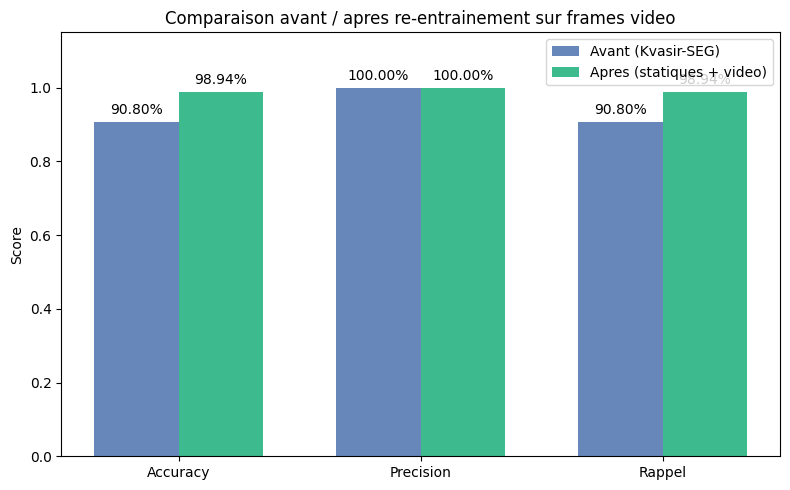

In [21]:
fig, ax = plt.subplots(figsize=(8, 5))
metric_names  = ['Accuracy', 'Precision', 'Rappel']
values_before = [metrics_old['accuracy'], metrics_old['precision'], metrics_old['recall']]
values_after  = [metrics_new['accuracy'], metrics_new['precision'], metrics_new['recall']]
x     = range(len(metric_names))
width = 0.35
bars1 = ax.bar([i - width/2 for i in x], values_before, width,
               label='Avant (Kvasir-SEG)', color='#4C72B0', alpha=0.85)
bars2 = ax.bar([i + width/2 for i in x], values_after, width,
               label='Apres (statiques + video)', color='#1baf7a', alpha=0.85)
ax.set_ylim(0, 1.15)
ax.set_xticks(list(x))
ax.set_xticklabels(metric_names)
ax.set_ylabel('Score')
ax.set_title('Comparaison avant / apres re-entrainement sur frames video')
ax.legend()
for bars in [bars1, bars2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                '{:.2%}'.format(bar.get_height()), ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('comparaison_avant_apres.png', dpi=150, bbox_inches='tight')
plt.show()


### Résumé des résultats après le réentraînement

Le modèle YOLO a été réentraîné en intégrant des images annotées supplémentaires provenant du dataset Hyper-Kvasir. Les performances ont ensuite été comparées avec celles du modèle initial sur le même jeu de validation.

Les résultats montrent une amélioration significative des performances globales :

| Métrique  |    Avant |    Après | Évolution |
| --------- | -------: | -------: | --------: |
| Accuracy  |  90.80 % |  98.94 % |   +8.14 % |
| Precision | 100.00 % | 100.00 % |    Stable |
| Recall    |  90.80 % |  98.94 % |   +8.14 % |

L'accuracy est passée de **90.80 %** à **98.94 %**, ce qui indique une amélioration importante de la capacité du modèle à classer correctement les images.

La **précision est restée à 100 %**, ce qui signifie que toutes les détections positives produites par le modèle correspondent effectivement à des polypes, sans augmentation des faux positifs.

Le **rappel (Recall)** a progressé de **90.80 %** à **98.94 %**, montrant que le modèle détecte désormais une proportion beaucoup plus importante des polypes présents dans les images, avec une réduction notable des faux négatifs.

Dans l'ensemble, l'ajout des nouvelles annotations issues du dataset Hyper-Kvasir a permis d'améliorer sensiblement la capacité de généralisation du modèle tout en conservant une précision parfaite. Ces résultats montrent que l'enrichissement du jeu d'entraînement a eu un impact positif sur les performances de détection et renforce la robustesse du modèle pour la détection des polypes.
.